<a href="https://colab.research.google.com/github/prabhakaran-layam-git/GEN_AI/blob/main/Pima_Indian_Classification_Draw_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#!/usr/bin/env python

# coding: utf-8

# In[7]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Create your first MLP in Keras
from keras.models import Sequential
from keras.layers import Dense
import numpy


In [7]:
def draw_model_view(model_instance, hidden_layers=None):
    """Architecture visualization with custom colors, neuron names, output arrow, and bias nodes.
    Args:
        model_instance: sklearn or Keras model
        hidden_layers: list of hidden layer sizes for sklearn models (e.g., [4, 3] for 2 hidden layers)
                      If None, defaults to [4, 3] for sklearn models   """

    layer_sizes = []

    # Check if it's a sklearn linear model (LinearRegression, Ridge, etc.)
    if hasattr(model_instance, 'coef_'):
        # For sklearn linear models: input features -> hidden layers -> output
        coef = model_instance.coef_
        if coef.ndim == 1:
            n_features = len(coef)
            n_outputs = 1
        else:
            n_features, n_outputs = coef.shape
        # Add hidden layers for visualization (default: 2 hidden layers with 4 and 3 neurons)

        if hidden_layers is None:
            hidden_layers = [4, 3]
        layer_sizes = [n_features] + hidden_layers + [n_outputs]

    # Check if it's a Keras/TensorFlow model

    elif hasattr(model_instance, 'layers'):
        if hasattr(model_instance.layers[0], 'input_shape'):
            layer_sizes.append(model_instance.layers[0].input_shape[-1])
        else:
            layer_sizes.append(model_instance.input_shape[-1])
        for layer in model_instance.layers:
            if hasattr(layer, 'units'):
                layer_sizes.append(layer.units)
    else:
        print("Unsupported model type for visualization")
        return

    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_facecolor('#fdfdfd')
    v_spacing = 1.0 / max(layer_sizes + [max(layer_sizes)])
    h_spacing = 1.0 / (len(layer_sizes) - 1)
    node_coords = []
    bias_coords = []
    for i, size in enumerate(layer_sizes):
        x = i * h_spacing
        layer_nodes = []
        for j in range(size):
            y = 0.5 + (j - (size - 1) / 2.0) * v_spacing
            layer_nodes.append((x, y))
        node_coords.append(layer_nodes)
        if i < len(layer_sizes) - 1:
            bias_y = layer_nodes[-1][1] + v_spacing
            bias_coords.append((x, bias_y))

    # Draw Connections
    for i in range(len(node_coords) - 1):
        for start in node_coords[i]:
            for end in node_coords[i+1]:
                ax.annotate('', xy=end, xytext=start,
                            arrowprops=dict(arrowstyle='-', color='#2c3e50', alpha=0.6, lw=1.2))
        b_start = bias_coords[i]
        for end in node_coords[i+1]:
            ax.annotate('', xy=end, xytext=b_start,
                        arrowprops=dict(arrowstyle='-', color='#e67e22', alpha=0.7, lw=1.5, ls='--'))

    # Colors: Input (Light Violet), Hidden (Pale Yellow), Output (Light Green)

    # Dynamically create colors and prefixes for any number of layers

    num_layers = len(layer_sizes)
    colors = ['#DDA0DD']  # Input layer - Light Violet
    layer_prefixes = ['In']
    # Add colors and prefixes for hidden layers

    for h in range(num_layers - 2):
        colors.append('#FFF9C4')  # Hidden layers - Pale Yellow
        layer_prefixes.append(f'H{h+1}')
    colors.append('#90EE90')  # Output layer - Light Green
    layer_prefixes.append('Out')
    for i, layer in enumerate(node_coords):
        c = colors[i] if i < len(colors) else colors[-1]
        prefix = layer_prefixes[i] if i < len(layer_prefixes) else f'L{i}'
        for j, (x, y) in enumerate(layer):
            circle = plt.Circle((x, y), v_spacing/3.5, color=c, ec='k', zorder=4)
            ax.add_artist(circle)
            neuron_name = f"{prefix}_{j+1}"
            # Darker text for light backgrounds
            text_color = 'black'
            ax.text(x, y, neuron_name, ha='center', va='center', fontsize=7, color=text_color, fontweight='bold', zorder=5)
            if i == len(node_coords) - 1:
                ax.annotate('', xy=(x + 0.1, y), xytext=(x, y),
                            arrowprops=dict(arrowstyle='->', color=c, lw=2, mutation_scale=20))
                ax.text(x + 0.11, y, 'Prediction', va='center', fontsize=12, fontweight='bold', color='#2ecc71')

        if i < len(bias_coords):
            bx, by = bias_coords[i]
            bias_circle = plt.Circle((bx, by), v_spacing/3.5, color='orange', ec='k', zorder=4)
            ax.add_artist(bias_circle)
            ax.text(bx, by, '+1', ha='center', va='center', fontsize=8, color='black', fontweight='bold', zorder=5)
            ax.text(bx, by + v_spacing/2.5, f'Bias_{prefix}', ha='center', fontsize=8, color='orange', fontweight='bold')
        ax.text(i * h_spacing, 1.15, f'{prefix} Layer\n({layer_sizes[i]} Neurons)', ha='center', fontsize=11, fontweight='bold')
    ax.set_title("Model Architecture Visualization", fontsize=16, pad=60)
    ax.axis('off')
    plt.xlim(-0.15, 1.3)
    plt.ylim(-0.15, 1.35)
    plt.tight_layout()
    plt.show()

    # Create weights table

    fig2, ax2 = plt.subplots(figsize=(12, max(3, len(layer_sizes) * 0.6)))
    ax2.axis('off')
    # Calculate weights and biases for each layer connection
    table_data = []
    total_weights = 0
    total_biases = 0
    total_params = 0

    for i in range(len(layer_sizes) - 1):
        from_layer = layer_prefixes[i]
        to_layer = layer_prefixes[i + 1]
        from_size = layer_sizes[i]
        to_size = layer_sizes[i + 1]
        weights = from_size * to_size
        biases = to_size
        params = weights + biases
        total_weights += weights
        total_biases += biases
        total_params += params
        calculation = f"{from_size} \u00d7 {to_size}"
        table_data.append([
            f"{from_layer} \u2192 {to_layer}",
            calculation,
            str(weights),
            str(biases),
            str(params)
        ])

    # Add total row

    table_data.append([
        "TOTAL",
        "-",
        str(total_weights),
        str(total_biases),
        str(total_params)
    ])

    # Column headers

    columns = ['Layer Connection', 'Weight Calculation', 'Weights', 'Biases', 'Total Params']
    # Create table
    table = ax2.table(
        cellText=table_data,
        colLabels=columns,
        cellLoc='center',
        loc='center',
        colColours=['#4a90d9'] * len(columns)
    )

    # Style the table

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)

    # Style header cells
    for j in range(len(columns)):
        table[(0, j)].set_text_props(color='white', fontweight='bold')

    # Style total row (last row)
    last_row = len(table_data)
    for j in range(len(columns)):
        table[(last_row, j)].set_facecolor('#f0f0f0')
        table[(last_row, j)].set_text_props(fontweight='bold')
    ax2.set_title("Model Weights Summary", fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

In [11]:
# In[6]:
# fix random seed for reproducibility
numpy.random.seed(7)
# load pima indians dataset
dataset = numpy.loadtxt("/content/dataset/pima-indians_classification_train.csv", delimiter=",")
# split into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]
# In[7]:
# create model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

# In[8]:
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the model
model.fit(X, Y, epochs=150, batch_size=10)

# evaluate the model
scores = model.evaluate(X, Y)

print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5729 - loss: 4.8652
Epoch 2/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4102 - loss: 1.1384
Epoch 3/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4180 - loss: 0.8592
Epoch 4/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5951 - loss: 0.7653
Epoch 5/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6250 - loss: 0.7099
Epoch 6/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6432 - loss: 0.6867
Epoch 7/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6471 - loss: 0.6784
Epoch 8/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6523 - loss: 0.6717
Epoch 9/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6510 - loss: 0.6675
Epoch 10/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6497 - loss: 0.6641
Epoch 11/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6458 - loss: 0.6599
Epoch 12/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

In [12]:

import numpy as np

# Predict diabetes for new samples (3 new patients)
samples = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50],   # Sample 1
                    [1, 85, 66, 29, 0, 26.6, 0.351, 31],    # Sample 2
                    [8, 183, 64, 0, 0, 23.3, 0.672, 32]])   # Sample 3

# Standardize the new data using the same scaler
#samples_scaled = scaler.transform(samples)
# In[10]:

# Predict diabetes (returns probabilities)
predictions = model.predict(samples)
# Convert probabilities to class labels (0 or 1)
predicted_classes = (predictions > 0.5).astype(int)
# Output predictions

print("Predictions for the samples (0 = No Diabetes, 1 = Diabetes):")
print(predicted_classes.flatten())



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Predictions for the samples (0 = No Diabetes, 1 = Diabetes):
[1 0 0]


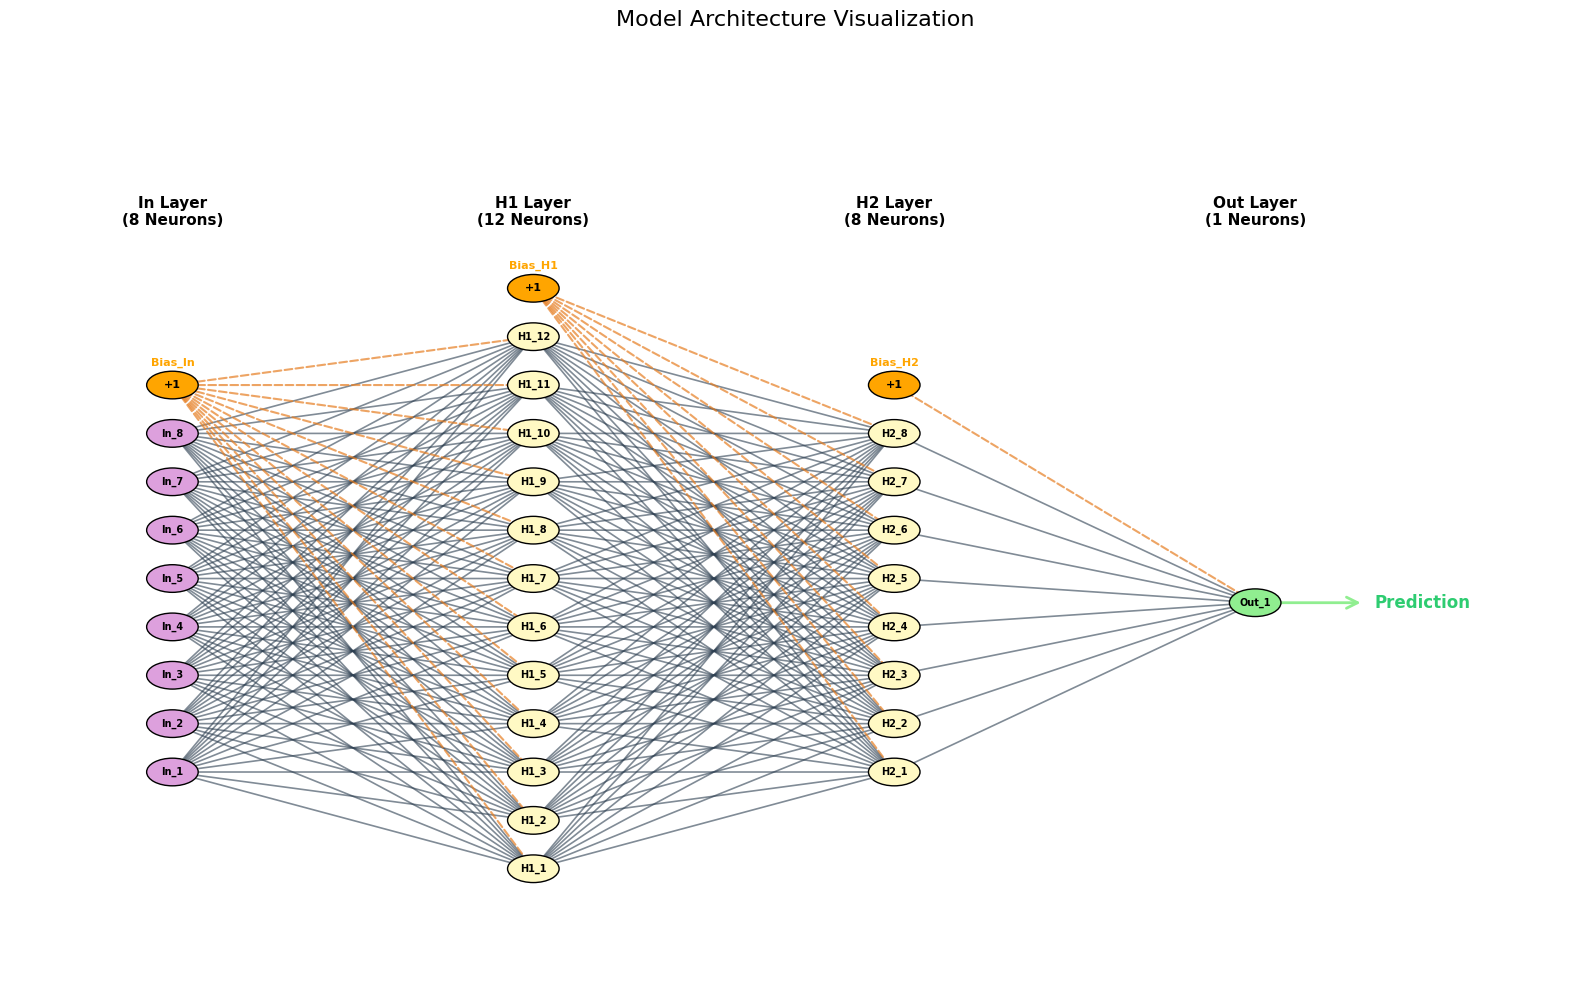

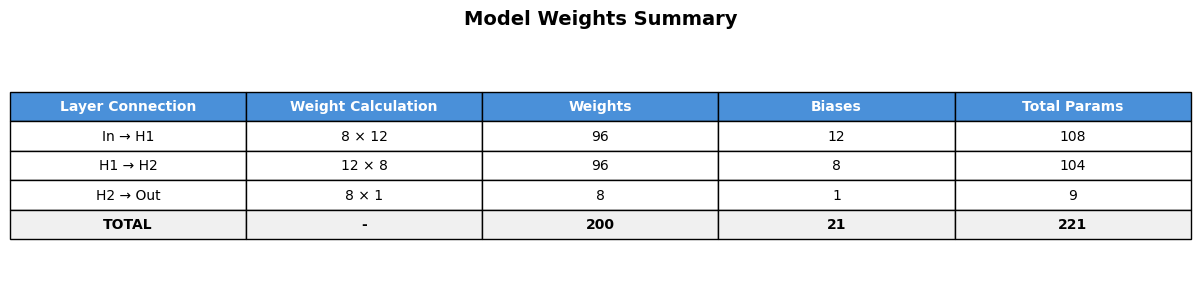

In [13]:
draw_model_view(model)